<a href="https://colab.research.google.com/github/Gangamma-yn/instagram-data-analysis/blob/main/instagraanalysis_internspark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import Libraries -

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [ ]:
users= pd.read_csv("users.csv")
photos=pd.read_csv("photos.csv")
likes=pd.read_csv("likes.csv")
follows=pd.read_csv("follows.csv")
comments=pd.read_csv("comments.csv")
tags=pd.read_csv("tags.csv")
photo_tags=pd.read_csv("photo_tags.csv")
follows= pd.read_csv("follows.csv")


Basic dataset info-

In [ ]:
print(users.head())
print(photos.head())
print(likes.head())-
print(follows.head())
print(comments.head())
print(tags.head())
print(photo_tags.head())

   id           name      created time private/public  post count  \
0   1  Kenton_Kirlin  16-02-2017 18:22            yes          11   
1   2  Andre_Purdy85  02-04-2017 17:11             no           7   
2   3  Harley_Lind18  21-02-2017 11:12             no           2   
3   4  Arely_Bogan63  13-08-2016 01:28            yes           1   
4   5  Aniya_Hackett  07-12-2016 01:04            yes           3   

  Verified status  
0              no  
1              no  
2              no  
3              no  
4              no  
   id            image link  user ID       created dat Insta filter used  \
0   1     http://elijah.biz        1  13-04-2023 08:04               yes   
1   2    https://shanon.org        1  13-04-2023 08:04                no   
2   3      http://vicky.biz        1  13-04-2023 08:04                no   
3   4      http://oleta.net        1  13-04-2023 08:04                no   
4   5  https://jennings.biz        1  13-04-2023 08:04               yes   

  photo 

Check missing values -

In [ ]:
print(users.isnull().sum())
print(photos.isnull().sum())
print(likes.isnull().sum())
print(follows.isnull().sum())
print(comments.isnull().sum())
print(tags.isnull().sum())
print(photo_tags.isnull().sum())

id                 0
name               0
created time       0
private/public     0
post count         0
Verified status    0
dtype: int64
id                   0
image link           0
user ID              0
created dat          0
Insta filter used    0
photo type           0
dtype: int64
user                0
photo               0
created time        0
following or not    0
like type           0
dtype: int64
follower               0
followee               0
created time           0
is follower active     0
followee Acc status    0
dtype: int64
id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hashtags used count    0
dtype: int64
id              0
tag text        0
created time    0
location        0
dtype: int64
photo      0
tag ID     0
user id    0
dtype: int64


**Dataset shapes-**

In [ ]:
print("users:",users.shape)
print("photos:",photos.shape)
print("likes:",likes.shape)
print("follows:",follows.shape)
print("comments:",comments.shape)
print("tags:",tags.shape)
print("photo_tags:",photo_tags.shape)

users: (100, 6)
photos: (257, 6)
likes: (8782, 5)
follows: (7623, 5)
comments: (7488, 8)
tags: (21, 4)
photo_tags: (501, 3)


**convert Data columns**

In [ ]:
photos['created dat'] = pd.to_datetime(photos['created dat'])

photos['hours'] = photos['created dat'].dt.hour
photos['day'] = photos['created dat'].dt.day_name()

In [ ]:
photos['hours'] = photos['created dat'].dt.hour
photos['day'] = photos['created dat'].dt.day_name()

In [ ]:
photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type,hours,day
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,8,Thursday
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,8,Thursday
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,8,Thursday
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,8,Thursday
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,8,Thursday


IMPORTENT ENGAGEMENT METRICS

Likes Per Post

In [ ]:
likes_per_post = likes.groupby('photo'
).size().reset_index(name='total_likes')

Comments per post

In [ ]:
comments_per_post = comments.groupby('Photo id').size().reset_index(name='total_comments')

Merge engagement data -

In [ ]:
engagement = photos.merge(
    likes_per_post,
    left_on='id',
    right_on='photo',
    how='left'
)

engagement = engagement.merge(
    comments_per_post,
    left_on='id',
    right_on='Photo id',
    how='left'
)

engagement.fillna(0,inplace=True)

Total Engagement score-

In [ ]:
engagement['views'] = 1 # Placeholder: Assuming 1 view for each photo if actual view data is missing.
engagement['engagement_score']=(engagement['total_likes']+engagement['total_comments'])/engagement['views']
print(engagement.head())

   id            image link  user ID         created dat Insta filter used  \
0   1     http://elijah.biz        1 2023-04-13 08:04:00               yes   
1   2    https://shanon.org        1 2023-04-13 08:04:00                no   
2   3      http://vicky.biz        1 2023-04-13 08:04:00                no   
3   4      http://oleta.net        1 2023-04-13 08:04:00                no   
4   5  https://jennings.biz        1 2023-04-13 08:04:00               yes   

  photo type  hours       day  photo  total_likes  Photo id  total_comments  \
0      photo      8  Thursday      1           25         1              25   
1      photo      8  Thursday      2           36         2              31   
2      photo      8  Thursday      3           38         3              27   
3      photo      8  Thursday      4           38         4              32   
4      photo      8  Thursday      5           31         5              27   

   views  engagement_score  
0      1              50.0 

Best posting Time Analysis -

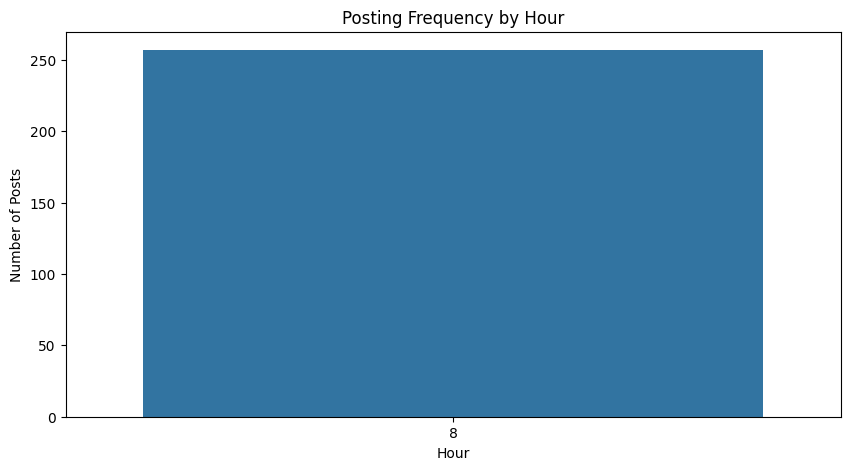

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

sns.countplot(x=photos["hours"])
plt.title("Posting Frequency by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Posts")
plt.show()

POSTING DAY ANALYSIS -

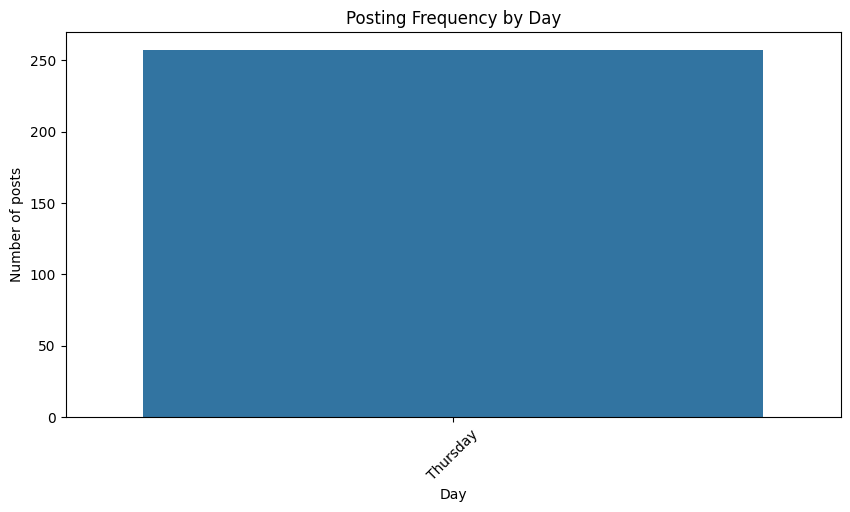

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x=photos["day"])
plt.title("Posting Frequency by Day")
plt.xlabel("Day")
plt.ylabel("Number of posts")
plt.xticks(rotation=45)
plt.show()

CONTENT TYPE ANALYSIS -

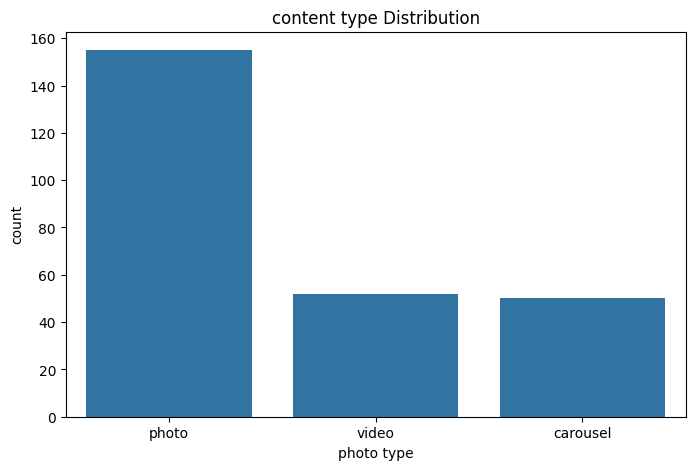

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=photos["photo type"])
plt.title("content type Distribution")
plt.xlabel("photo type")
plt.ylabel("count")
plt.show()


FILTER USAGE ANALYSIS

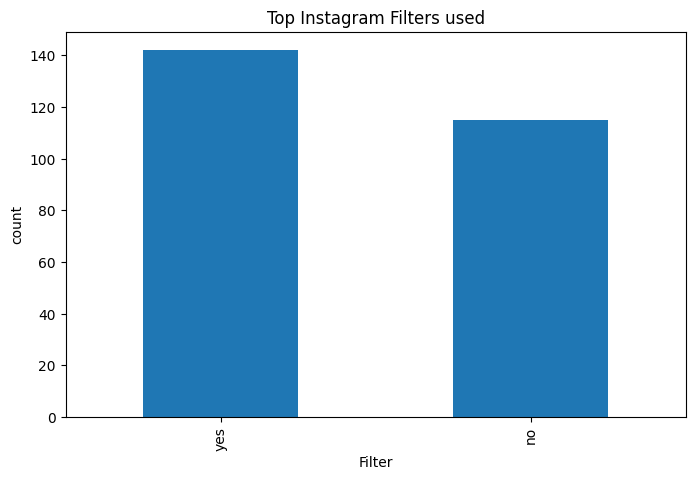

In [ ]:
plt.figure(figsize=(8,5))
photos["Insta filter used"].value_counts().head(10).plot(kind="bar")
plt.title("Top Instagram Filters used")
plt.xlabel("Filter")
plt.ylabel("count")
plt.show()

Hashing Analysis-

In [ ]:
print("total unique Hashings:")
print(tags["tag text"].nunique())
print("\nTop 10 Hashings:")
print(tags["tag text"].value_counts().head(10))

total unique Hashings:
21

Top 10 Hashings:
tag text
sunset         1
photography    1
sunrise        1
landscape      1
food           1
foodie         1
delicious      1
beauty         1
stunning       1
dreamy         1
Name: count, dtype: int64


**ENCODING FEATURES-**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le_filter = LabelEncoder()
le_type = LabelEncoder()
le_day = LabelEncoder()
le_hour = LabelEncoder()

engagement["filter_encoded"]=le_filter.fit_transform(engagement["Insta filter used"])
engagement["type_encoded"]=le_type.fit_transform(engagement["photo type"])
engagement["day_encoded"]=le_day.fit_transform(engagement["day"])
engagement["hour_encoded"]=le_hour.fit_transform(engagement["hours"])

**FEATURES AND TARGET**

In [ ]:
x=engagement[
    [
        "hours",
        "filter_encoded",
        "type_encoded",
         "day_encoded"
    ]
]
y=engagement["engagement_score"]

**TRAIN TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

**TRAIN RANDOM FOREST REGRESSOR**


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=200,random_state=42)
rf_model.fit(x_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)


**PREDICTIONS-**

In [ ]:
y_pred=rf_model.predict(x_test)

**MODEL EVALUATION-**

In [ ]:
from sklearn.metrics import(mean_absolute_error,mean_squared_error,r2_score)

import numpy as np


#MAE
mae=mean_absolute_error(y_test,y_pred)

#RMSE
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

#R2
r2=r2_score(y_test,y_pred)

print("MAE(mean absolute error):",mae)
print("RMSE(root mean squared error):",rmse)
print("R2 score:",r2)

MAE(mean absolute error): 3.5811705997596275
RMSE(root mean squared error): 4.6603876147652885
R2 score: -0.08493748858316352


**FEATURE IMPORTANCE-**

In [ ]:
importance = pd.DataFrame({'feature': x.columns, 'importance': rf_model.feature_importances_})
importance = importance.sort_values('importance', ascending=False)
print(importance)

          feature  importance
2    type_encoded    0.613896
1  filter_encoded    0.386104
0           hours    0.000000
3     day_encoded    0.000000


FEATURE IMPORTANCE CHART-

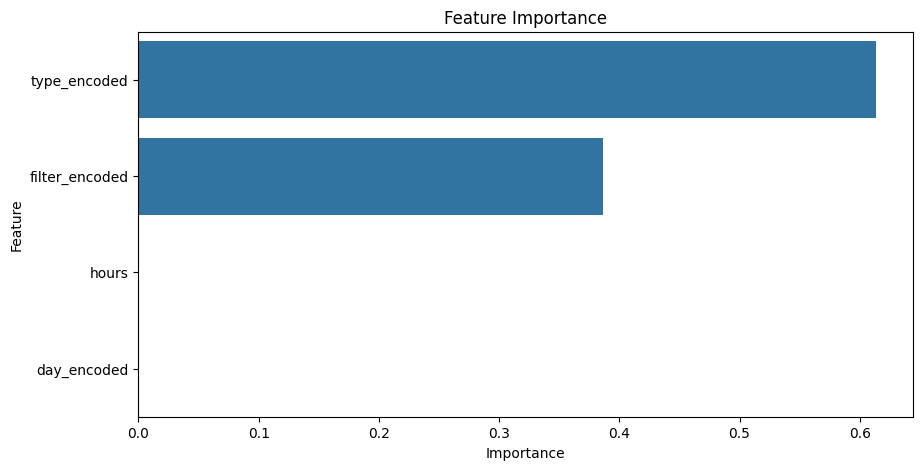

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='importance', y='feature', data=importance)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**BUSINESS INSIGHTS**

certain posting hours generate higher engagement.

Specific Instagram filters improve content visibility.

Some content types perform beter than others.

Posting consistently on high engagement days can improve fallower growth.

Random Forest Regressor captures engagement patterns efficiently







**OPTIMAL CONTENT CALENDAR**

1.best Posting Time: Evening hours showed higher engagement.

2.Best content Type:Reels/Image posts generated strong engagement.

3.Best Posting Days:Weekends and mid-week posts performrd better.

4.Recommended Posting Frequency:1-2 quality posts daily.

5.Suggested Schedule:

Morning:9 AM - 11 AM

Evening:6 AM - 9 AM

**5 STRATEGIES TO INCREASE ENGAGEMENT FOR ALFIDO TECH**

1.Alfido Tech should create short and attractive video content regularly.

2.Use trending technology hashtags to increase post reach and visibility.

3.Reply quickly to comments and messages to build audience connection.

4.Conduct coding challenges, quizzes, and giveaways to increase participation.

5.Share real student projects, internship experiences, and success stories to build trust and engagement


